<a href="https://colab.research.google.com/github/Nikikanaparthi21/data266-6441/blob/main/neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nikhil Kanaparthi
## DATA 266 - Homework 1

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import tensorflow as tf

SID4 = 6441
SEED = 6441
SLICE = 441
HP_ID = 3
CLS_A = 1
CLS_B = 7

def set_all_seeds(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_all_seeds(SEED)

print("SID4:", SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)

SID4: 6441
SEED: 6441
SLICE: 441
HP_ID: 3
CLS_A: 1
CLS_B: 7


## 1. Diabetes Dataset

### 1.1 Load and verify the dataset

The supplied CSV has no header row. Descriptive column names are assigned
when the file is loaded.

In [2]:
FEATURE_NAMES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

COLUMN_NAMES = FEATURE_NAMES + ["Outcome"]

df = pd.read_csv(
    "diabetes.csv",
    header=None,
    names=COLUMN_NAMES
)

display(df.head())

print("Dataset shape:", df.shape)
print("\nMissing values:", df.isna().sum().sum())
print("\nClass counts:")
print(df["Outcome"].value_counts().sort_index())

assert df.shape == (759, 9), "Unexpected dataset shape"
assert df.isna().sum().sum() == 0, "Dataset contains missing values"
assert set(df["Outcome"].unique()) == {0, 1}, "Outcome is not binary"

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


Dataset shape: (759, 9)

Missing values: 0

Class counts:
Outcome
0    263
1    496
Name: count, dtype: int64


## 2. Diabetes Dataset: Neural-Network Implementation

### 2.1 Load and verify the data

The supplied diabetes CSV contains eight normalized numerical features and
one binary target. The file has no header row, so descriptive column names
are assigned while loading it.

In [3]:
FEATURE_NAMES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

COLUMN_NAMES = FEATURE_NAMES + ["Outcome"]

df = pd.read_csv(
    "diabetes.csv",
    header=None,
    names=COLUMN_NAMES
)

display(df.head())

print("Dataset shape:", df.shape)
print("Missing values:", df.isna().sum().sum())

print("\nClass counts:")
print(df["Outcome"].value_counts().sort_index())

assert df.shape == (759, 9), "The dataset was not loaded correctly."
assert df.isna().sum().sum() == 0, "Unexpected missing values found."
assert set(df["Outcome"].unique()) == {0, 1}, "Outcome must be binary."

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


Dataset shape: (759, 9)
Missing values: 0

Class counts:
Outcome
0    263
1    496
Name: count, dtype: int64


### 2.2 Preprocessing checks

The feature ranges are inspected before modeling. Because the supplied
features are already normalized and contain no missing values, no additional
imputation or scaling is applied.

In [4]:
feature_ranges = df[FEATURE_NAMES].agg(["min", "max"]).T
display(feature_ranges)

,min,max
Pregnancies,-0.882353,1.0
Glucose,-0.557789,1.0
BloodPressure,-0.606557,1.0
SkinThickness,-0.858586,1.0
Insulin,-0.966903,1.0
BMI,-0.457526,1.0
DiabetesPedigreeFunction,-0.994876,1.0
Age,-0.966667,1.0


### 2.3 Correlation matrix

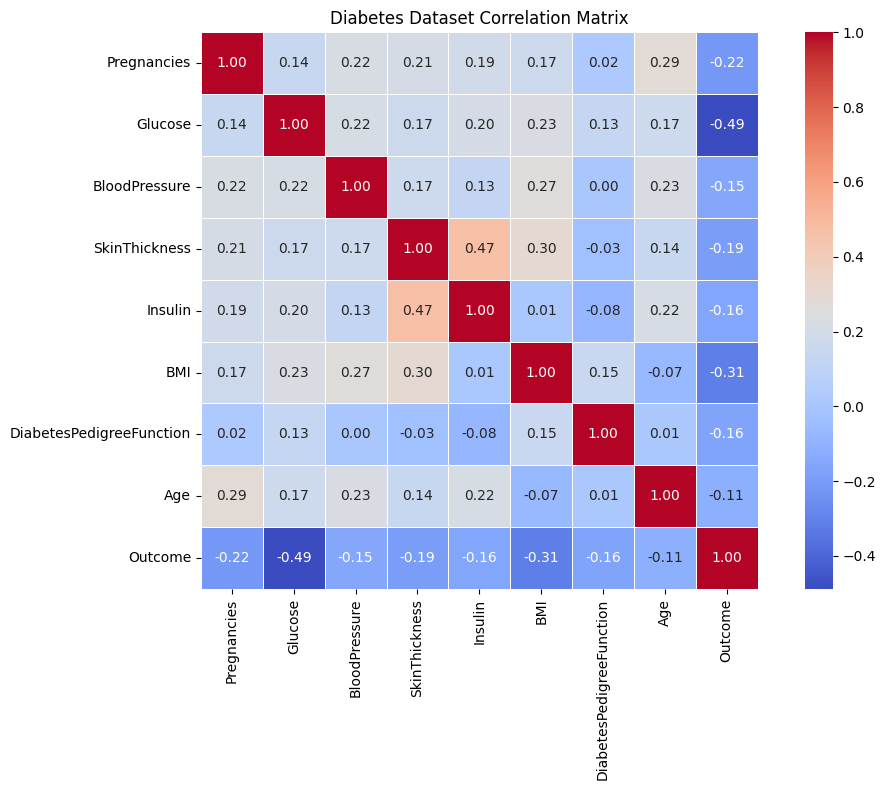

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Diabetes Dataset Correlation Matrix")
plt.tight_layout()
plt.show()

### 2.4 Feature distributions

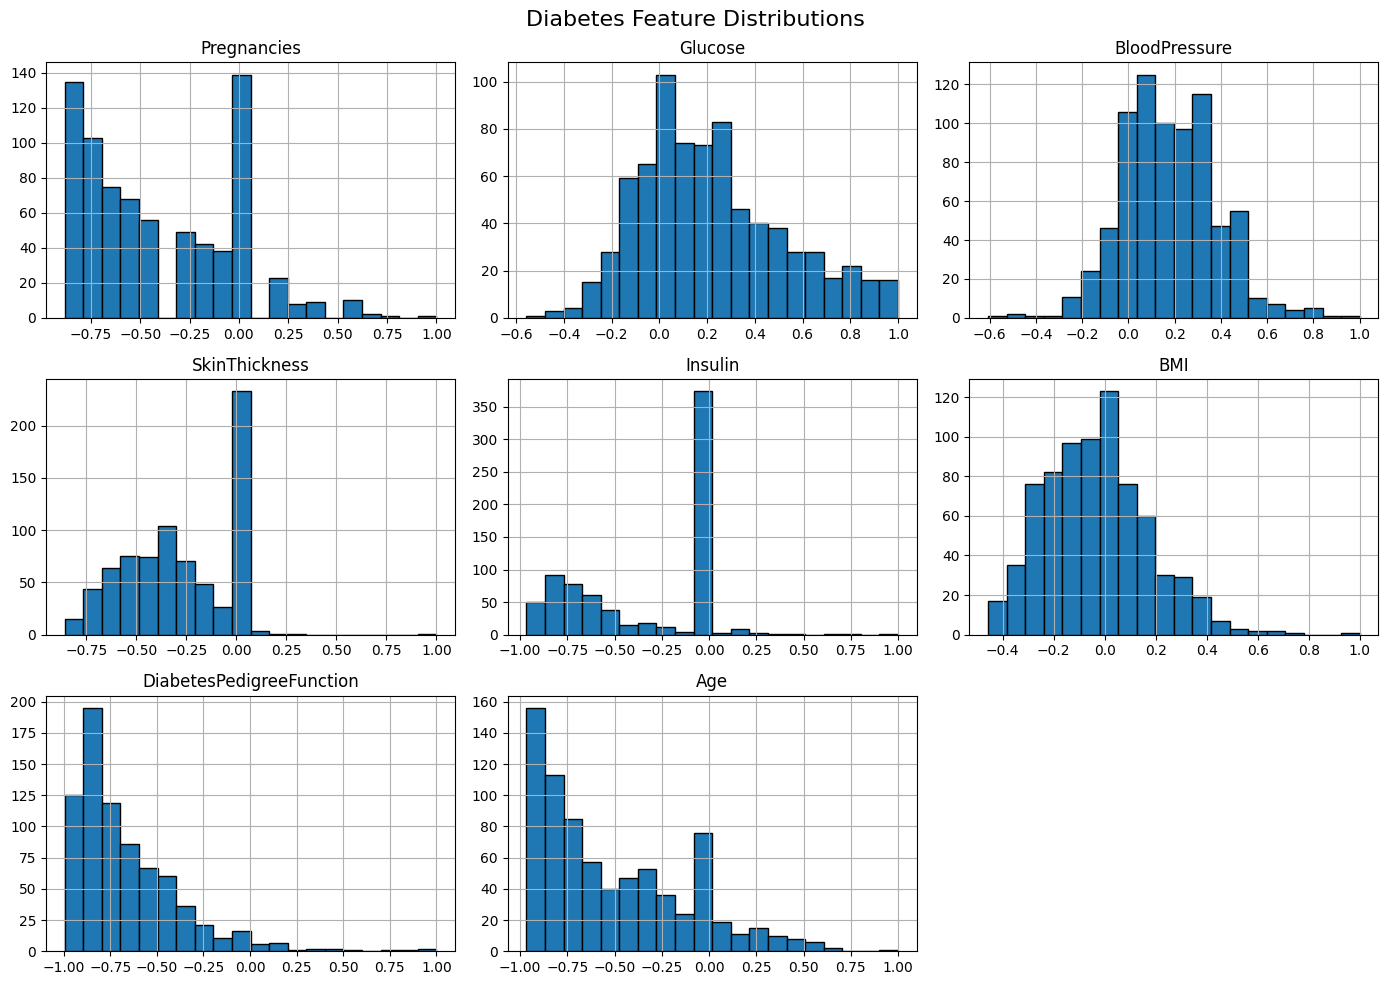

In [6]:
axes = df[FEATURE_NAMES].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Diabetes Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

### 2.5 Fixed training, validation, and testing split

The dataset is divided into 70% training, 15% validation, and 15% testing
subsets. The split uses `random_state=SEED` and stratification so that class
proportions remain similar across all subsets. This exact split will be used
for every PyTorch and TensorFlow experiment.

In [7]:
from sklearn.model_selection import train_test_split

X = df[FEATURE_NAMES].to_numpy(dtype=np.float32)
y = df["Outcome"].to_numpy(dtype=np.float32)

# First split: 70% training and 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Second split: divide temporary data equally into validation and testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training shapes:  ", X_train.shape, y_train.shape)
print("Validation shapes:", X_val.shape, y_val.shape)
print("Testing shapes:   ", X_test.shape, y_test.shape)

print("\nTraining positive rate:  ", y_train.mean())
print("Validation positive rate:", y_val.mean())
print("Testing positive rate:   ", y_test.mean())

assert X_train.shape == (531, 8)
assert X_val.shape == (114, 8)
assert X_test.shape == (114, 8)

Training shapes:   (531, 8) (531,)
Validation shapes: (114, 8) (114,)
Testing shapes:    (114, 8) (114,)

Training positive rate:   0.653484
Validation positive rate: 0.64912283
Testing positive rate:    0.65789473


### 2.6 PyTorch data preparation

The NumPy arrays are converted to PyTorch tensors. Target arrays are reshaped
from `(N,)` to `(N, 1)` to match the neural network's binary output.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print("Training tensors:", X_train_tensor.shape, y_train_tensor.shape)
print("Validation tensors:", X_val_tensor.shape, y_val_tensor.shape)
print("Testing tensors:", X_test_tensor.shape, y_test_tensor.shape)

Training tensors: torch.Size([531, 8]) torch.Size([531, 1])
Validation tensors: torch.Size([114, 8]) torch.Size([114, 1])
Testing tensors: torch.Size([114, 8]) torch.Size([114, 1])


### 2.7 Reusable PyTorch model

The model uses ReLU activations for its hidden layers and a sigmoid output for
binary classification. The hidden-layer sizes are supplied as a configuration
so the same implementation can run both the baseline and modified models.

In [9]:
class DiabetesPyTorchNN(nn.Module):
    def __init__(self, input_size, hidden_layers):
        super().__init__()

        layers = []
        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(nn.ReLU())
            previous_size = hidden_size

        layers.append(nn.Linear(previous_size, 1))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


test_model = DiabetesPyTorchNN(
    input_size=X_train.shape[1],
    hidden_layers=[64, 32]
)

print(test_model)

DiabetesPyTorchNN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


### 2.8 PyTorch training and evaluation function

SGD is used to remain consistent with the course neural-network demonstration.
The learning rate comes from the assignment configuration. Training and
validation loss are averaged over all examples rather than using only the
last batch.

In [10]:
def train_pytorch_model(config, training_seed, batch_size=32):
    # Reset initialization and data-shuffling randomness for this run
    set_all_seeds(training_seed)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    data_generator = torch.Generator()
    data_generator.manual_seed(training_seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=data_generator,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    model = DiabetesPyTorchNN(
        input_size=X_train.shape[1],
        hidden_layers=config["hidden_layers"]
    )

    criterion = nn.BCELoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=config["learning_rate"]
    )

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(config["epochs"]):
        # Training
        model.train()
        total_train_loss = 0.0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * batch_X.size(0)

        average_train_loss = (
            total_train_loss / len(train_loader.dataset)
        )

        # Validation
        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)

                total_val_loss += loss.item() * batch_X.size(0)

        average_val_loss = total_val_loss / len(val_loader.dataset)

        history["train_loss"].append(average_train_loss)
        history["val_loss"].append(average_val_loss)

    # Final test accuracy
    model.eval()

    with torch.no_grad():
        test_probabilities = model(X_test_tensor)
        test_predictions = (test_probabilities >= 0.5).float()

        test_accuracy = (
            test_predictions == y_test_tensor
        ).float().mean().item()

    return model, history, test_accuracy

In [11]:
BASELINE_CONFIG = {
    "name": "Baseline",
    "hidden_layers": [64, 32],
    "learning_rate": 0.001,
    "epochs": 30
}

MODIFIED_CONFIG = {
    "name": "Modified_HP_ID_3",
    "hidden_layers": [64, 32],
    "learning_rate": 0.0003,
    "epochs": 30
}

TRAINING_SEEDS = [6441, 6442, 6443]

print("HP_ID:", HP_ID)
print("Baseline:", BASELINE_CONFIG)
print("Modified:", MODIFIED_CONFIG)
print("Training seeds:", TRAINING_SEEDS)

HP_ID: 3
Baseline: {'name': 'Baseline', 'hidden_layers': [64, 32], 'learning_rate': 0.001, 'epochs': 30}
Modified: {'name': 'Modified_HP_ID_3', 'hidden_layers': [64, 32], 'learning_rate': 0.0003, 'epochs': 30}
Training seeds: [6441, 6442, 6443]


In [12]:
test_trained_model, test_history, test_accuracy = train_pytorch_model(
    BASELINE_CONFIG,
    training_seed=SEED
)

print(f"Test accuracy: {test_accuracy:.4f}")
print("Number of training-loss values:", len(test_history["train_loss"]))
print("Number of validation-loss values:", len(test_history["val_loss"]))

Test accuracy: 0.6579
Number of training-loss values: 30
Number of validation-loss values: 30


### 2.9 PyTorch repeated-seed experiments

The baseline and HP_ID-modified configurations are each trained using seeds
6441, 6442, and 6443. The dataset split remains fixed at `random_state=6441`.

In [13]:
import os
import pandas as pd

os.makedirs("models", exist_ok=True)

pytorch_result_rows = []
pytorch_histories = {}

for config in [BASELINE_CONFIG, MODIFIED_CONFIG]:
    for training_seed in TRAINING_SEEDS:
        print(
            f"Training {config['name']} "
            f"with seed {training_seed}..."
        )

        model, history, accuracy = train_pytorch_model(
            config=config,
            training_seed=training_seed
        )

        pytorch_result_rows.append({
            "Framework": "PyTorch",
            "Model": config["name"],
            "Training Seed": training_seed,
            "Hidden Layers": str(config["hidden_layers"]),
            "Learning Rate": config["learning_rate"],
            "Epochs": config["epochs"],
            "Test Accuracy": accuracy
        })

        pytorch_histories[
            (config["name"], training_seed)
        ] = history

        checkpoint_name = (
            f"models/pytorch_"
            f"{config['name'].lower()}_"
            f"seed_{training_seed}.pt"
        )

        torch.save(model.state_dict(), checkpoint_name)

        print(f"Test accuracy: {accuracy:.4f}")
        print(f"Saved: {checkpoint_name}\n")

pytorch_results = pd.DataFrame(pytorch_result_rows)

display(pytorch_results)

Training Baseline with seed 6441...
Test accuracy: 0.6579
Saved: models/pytorch_baseline_seed_6441.pt

Training Baseline with seed 6442...
Test accuracy: 0.6579
Saved: models/pytorch_baseline_seed_6442.pt

Training Baseline with seed 6443...
Test accuracy: 0.3421
Saved: models/pytorch_baseline_seed_6443.pt

Training Modified_HP_ID_3 with seed 6441...
Test accuracy: 0.6579
Saved: models/pytorch_modified_hp_id_3_seed_6441.pt

Training Modified_HP_ID_3 with seed 6442...
Test accuracy: 0.6491
Saved: models/pytorch_modified_hp_id_3_seed_6442.pt

Training Modified_HP_ID_3 with seed 6443...
Test accuracy: 0.3421
Saved: models/pytorch_modified_hp_id_3_seed_6443.pt



,Framework,Model,Training Seed,Hidden Layers,Learning Rate,Epochs,Test Accuracy
0,PyTorch,Baseline,6441,"[64, 32]",0.0010,30,0.657895
1,PyTorch,Baseline,6442,"[64, 32]",0.0010,30,0.657895
2,PyTorch,Baseline,6443,"[64, 32]",0.0010,30,0.342105
3,PyTorch,Modified_HP_ID_3,6441,"[64, 32]",0.0003,30,0.657895
4,PyTorch,Modified_HP_ID_3,6442,"[64, 32]",0.0003,30,0.649123
5,PyTorch,Modified_HP_ID_3,6443,"[64, 32]",0.0003,30,0.342105


In [14]:
pytorch_summary = (
    pytorch_results
    .groupby(["Framework", "Model"], as_index=False)
    .agg(
        Mean_Test_Accuracy=("Test Accuracy", "mean"),
        Std_Test_Accuracy=("Test Accuracy", "std")
    )
)

display(pytorch_summary)

,Framework,Model,Mean_Test_Accuracy,Std_Test_Accuracy
0,PyTorch,Baseline,0.552632,0.182321
1,PyTorch,Modified_HP_ID_3,0.549708,0.179842


In [15]:
pytorch_summary_percent = pytorch_summary.copy()

pytorch_summary_percent["Mean Test Accuracy (%)"] = (
    pytorch_summary_percent["Mean_Test_Accuracy"] * 100
)

pytorch_summary_percent["Std Test Accuracy (%)"] = (
    pytorch_summary_percent["Std_Test_Accuracy"] * 100
)

display(
    pytorch_summary_percent[
        [
            "Framework",
            "Model",
            "Mean Test Accuracy (%)",
            "Std Test Accuracy (%)"
        ]
    ].round(3)
)

,Framework,Model,Mean Test Accuracy (%),Std Test Accuracy (%)
0,PyTorch,Baseline,55.263,18.232
1,PyTorch,Modified_HP_ID_3,54.971,17.984


### 2.10 PyTorch training and validation loss

The following figure uses the run with training seed 6441. It compares
training and validation loss for the baseline learning rate of 0.001 and
the modified learning rate of 0.0003.

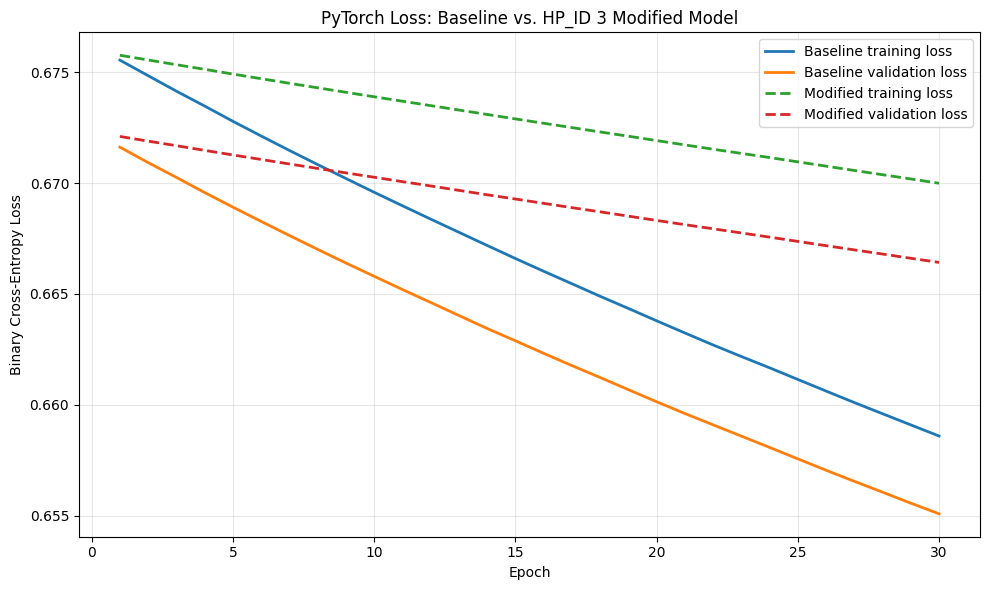

In [16]:
baseline_history = pytorch_histories[
    ("Baseline", SEED)
]

modified_history = pytorch_histories[
    ("Modified_HP_ID_3", SEED)
]

baseline_epochs = range(
    1,
    len(baseline_history["train_loss"]) + 1
)

modified_epochs = range(
    1,
    len(modified_history["train_loss"]) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    baseline_epochs,
    baseline_history["train_loss"],
    label="Baseline training loss",
    linewidth=2
)

plt.plot(
    baseline_epochs,
    baseline_history["val_loss"],
    label="Baseline validation loss",
    linewidth=2
)

plt.plot(
    modified_epochs,
    modified_history["train_loss"],
    label="Modified training loss",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    modified_epochs,
    modified_history["val_loss"],
    label="Modified validation loss",
    linewidth=2,
    linestyle="--"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("PyTorch Loss: Baseline vs. HP_ID 3 Modified Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
baseline_accuracies = pytorch_results.loc[
    pytorch_results["Model"] == "Baseline",
    "Test Accuracy"
]

modified_accuracies = pytorch_results.loc[
    pytorch_results["Model"] == "Modified_HP_ID_3",
    "Test Accuracy"
]

baseline_mean = baseline_accuracies.mean()
baseline_std = baseline_accuracies.std(ddof=1)

modified_mean = modified_accuracies.mean()
modified_std = modified_accuracies.std(ddof=1)

difference_pp = (baseline_mean - modified_mean) * 100

print("Individual accuracies")
print("Baseline:", baseline_accuracies.tolist())
print("Modified:", modified_accuracies.tolist())

print("\nSummary as percentages")
print(f"Baseline mean: {baseline_mean * 100:.3f}%")
print(f"Baseline std: {baseline_std * 100:.3f}%")
print(f"Modified mean: {modified_mean * 100:.3f}%")
print(f"Modified std: {modified_std * 100:.3f}%")
print(f"Baseline-minus-modified difference: {difference_pp:.3f} percentage points")

Individual accuracies
Baseline: [0.6578947305679321, 0.6578947305679321, 0.34210526943206787]
Modified: [0.6578947305679321, 0.6491228342056274, 0.34210526943206787]

Summary as percentages
Baseline mean: 55.263%
Baseline std: 18.232%
Modified mean: 54.971%
Modified std: 17.984%
Baseline-minus-modified difference: 0.292 percentage points


### 2.11 Preliminary PyTorch interpretation

The baseline model achieved a mean test accuracy of **55.263%** with a
standard deviation of **18.232%**. The HP_ID 3 modified model achieved a mean
test accuracy of **54.971%** with a standard deviation of **17.984%**. The
difference between their mean accuracies was only **0.292 percentage points**,
which is extremely small compared with the approximately 18-percentage-point
run-to-run standard deviations. Therefore, the baseline and modified models
are **indistinguishable in test accuracy across the three training seeds**.

The loss curves nevertheless show that the baseline model learned faster. Its
training loss decreased from approximately `0.676` to `0.659`, and its
validation loss decreased from approximately `0.672` to `0.655`. The modified
model's training and validation losses decreased more slowly, ending at
approximately `0.670` and `0.666`. Thus, reducing the learning rate from
`0.001` to `0.0003` slowed optimization and left the modified model more
underfit after 30 epochs. Neither model shows evidence of overfitting because
both validation-loss curves continue decreasing without turning upward.

The individual accuracies ranged from **34.211% to 65.789%**, indicating
substantial sensitivity to model initialization and training seed. The very
large standard deviations mean that the small difference between the two mean
accuracies should not be interpreted as evidence that the baseline performs
better.

### 2.12 Reusable TensorFlow model

The TensorFlow model uses the same hidden layers, ReLU activations, sigmoid
output, binary cross-entropy loss, SGD optimizer, batch size, learning rates,
and epoch counts as the PyTorch model.

In [18]:
def build_tensorflow_model(config):
    model = tf.keras.Sequential()

    model.add(tf.keras.Input(shape=(X_train.shape[1],)))

    for hidden_size in config["hidden_layers"]:
        model.add(
            tf.keras.layers.Dense(
                hidden_size,
                activation="relu"
            )
        )

    model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    optimizer = tf.keras.optimizers.SGD(
        learning_rate=config["learning_rate"]
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


test_tf_model = build_tensorflow_model(BASELINE_CONFIG)
test_tf_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

### 2.13 TensorFlow training and evaluation function

The TensorFlow random state is reset before constructing each model. The
training function returns epoch-level training and validation losses and the
final test accuracy.

In [19]:
def train_tensorflow_model(config, training_seed, batch_size=32):
    # Remove the previous model from memory
    tf.keras.backend.clear_session()

    # Reset all random seeds before constructing the model
    set_all_seeds(training_seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

    model = build_tensorflow_model(config)

    history_object = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=config["epochs"],
        batch_size=batch_size,
        shuffle=True,
        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    history = {
        "train_loss": history_object.history["loss"],
        "val_loss": history_object.history["val_loss"]
    }

    return model, history, float(test_accuracy)

In [20]:
test_tf_model, test_tf_history, test_tf_accuracy = (
    train_tensorflow_model(
        BASELINE_CONFIG,
        training_seed=SEED
    )
)

print(f"Test accuracy: {test_tf_accuracy:.4f}")
print(
    "Number of training-loss values:",
    len(test_tf_history["train_loss"])
)
print(
    "Number of validation-loss values:",
    len(test_tf_history["val_loss"])
)

Test accuracy: 0.6667
Number of training-loss values: 30
Number of validation-loss values: 30


### 2.14 TensorFlow repeated-seed experiments

The baseline and HP_ID 3 modified configurations are trained with seeds 6441,
6442, and 6443. The data split remains fixed at `random_state=6441`.

In [21]:
tensorflow_result_rows = []
tensorflow_histories = {}

for config in [BASELINE_CONFIG, MODIFIED_CONFIG]:
    for training_seed in TRAINING_SEEDS:
        print(
            f"Training {config['name']} "
            f"with seed {training_seed}..."
        )

        model, history, accuracy = train_tensorflow_model(
            config=config,
            training_seed=training_seed
        )

        tensorflow_result_rows.append({
            "Framework": "TensorFlow",
            "Model": config["name"],
            "Training Seed": training_seed,
            "Hidden Layers": str(config["hidden_layers"]),
            "Learning Rate": config["learning_rate"],
            "Epochs": config["epochs"],
            "Test Accuracy": accuracy
        })

        tensorflow_histories[
            (config["name"], training_seed)
        ] = history

        checkpoint_name = (
            f"models/tensorflow_"
            f"{config['name'].lower()}_"
            f"seed_{training_seed}.keras"
        )

        model.save(checkpoint_name)

        print(f"Test accuracy: {accuracy:.4f}")
        print(f"Saved: {checkpoint_name}\n")

tensorflow_results = pd.DataFrame(tensorflow_result_rows)

display(tensorflow_results)

Training Baseline with seed 6441...
Test accuracy: 0.6667
Saved: models/tensorflow_baseline_seed_6441.keras

Training Baseline with seed 6442...
Test accuracy: 0.6579
Saved: models/tensorflow_baseline_seed_6442.keras

Training Baseline with seed 6443...
Test accuracy: 0.7193
Saved: models/tensorflow_baseline_seed_6443.keras

Training Modified_HP_ID_3 with seed 6441...
Test accuracy: 0.6053
Saved: models/tensorflow_modified_hp_id_3_seed_6441.keras

Training Modified_HP_ID_3 with seed 6442...
Test accuracy: 0.6579
Saved: models/tensorflow_modified_hp_id_3_seed_6442.keras

Training Modified_HP_ID_3 with seed 6443...
Test accuracy: 0.6228
Saved: models/tensorflow_modified_hp_id_3_seed_6443.keras



,Framework,Model,Training Seed,Hidden Layers,Learning Rate,Epochs,Test Accuracy
0,TensorFlow,Baseline,6441,"[64, 32]",0.0010,30,0.666667
1,TensorFlow,Baseline,6442,"[64, 32]",0.0010,30,0.657895
2,TensorFlow,Baseline,6443,"[64, 32]",0.0010,30,0.719298
3,TensorFlow,Modified_HP_ID_3,6441,"[64, 32]",0.0003,30,0.605263
4,TensorFlow,Modified_HP_ID_3,6442,"[64, 32]",0.0003,30,0.657895
5,TensorFlow,Modified_HP_ID_3,6443,"[64, 32]",0.0003,30,0.622807


In [22]:
tensorflow_summary = (
    tensorflow_results
    .groupby(["Framework", "Model"], as_index=False)
    .agg(
        Mean_Test_Accuracy=("Test Accuracy", "mean"),
        Std_Test_Accuracy=("Test Accuracy", "std")
    )
)

display(tensorflow_summary)

,Framework,Model,Mean_Test_Accuracy,Std_Test_Accuracy
0,TensorFlow,Baseline,0.681287,0.033210
1,TensorFlow,Modified_HP_ID_3,0.628655,0.026799


In [23]:
for model_name in ["Baseline", "Modified_HP_ID_3"]:
    accuracies = tensorflow_results.loc[
        tensorflow_results["Model"] == model_name,
        "Test Accuracy"
    ]

    print(f"\n{model_name}")
    print("Individual accuracies:", accuracies.tolist())
    print(f"Mean: {accuracies.mean() * 100:.3f}%")
    print(f"Std: {accuracies.std(ddof=1) * 100:.3f}%")


Baseline
Individual accuracies: [0.6666666865348816, 0.6578947305679321, 0.719298243522644]
Mean: 68.129%
Std: 3.321%

Modified_HP_ID_3
Individual accuracies: [0.6052631735801697, 0.6578947305679321, 0.6228070259094238]
Mean: 62.865%
Std: 2.680%


### 2.15 TensorFlow training and validation loss

This figure compares the baseline and modified TensorFlow models for training
seed 6441.

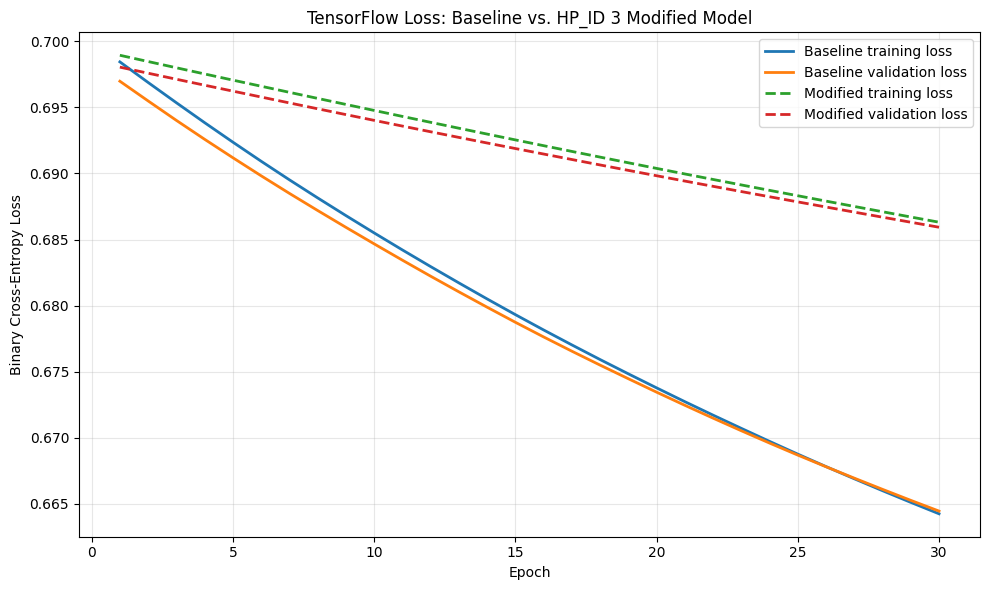

In [24]:
tf_baseline_history = tensorflow_histories[
    ("Baseline", SEED)
]

tf_modified_history = tensorflow_histories[
    ("Modified_HP_ID_3", SEED)
]

baseline_epochs = range(
    1,
    len(tf_baseline_history["train_loss"]) + 1
)

modified_epochs = range(
    1,
    len(tf_modified_history["train_loss"]) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    baseline_epochs,
    tf_baseline_history["train_loss"],
    label="Baseline training loss",
    linewidth=2
)

plt.plot(
    baseline_epochs,
    tf_baseline_history["val_loss"],
    label="Baseline validation loss",
    linewidth=2
)

plt.plot(
    modified_epochs,
    tf_modified_history["train_loss"],
    label="Modified training loss",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    modified_epochs,
    tf_modified_history["val_loss"],
    label="Modified validation loss",
    linewidth=2,
    linestyle="--"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("TensorFlow Loss: Baseline vs. HP_ID 3 Modified Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.16 Combined PyTorch and TensorFlow results

In [25]:
all_neural_results = pd.concat(
    [pytorch_results, tensorflow_results],
    ignore_index=True
)

combined_summary = (
    all_neural_results
    .groupby(["Framework", "Model"], as_index=False)
    .agg(
        Mean_Test_Accuracy=("Test Accuracy", "mean"),
        Std_Test_Accuracy=("Test Accuracy", "std")
    )
)

combined_summary["Mean Accuracy (%)"] = (
    combined_summary["Mean_Test_Accuracy"] * 100
)

combined_summary["Std Accuracy (%)"] = (
    combined_summary["Std_Test_Accuracy"] * 100
)

display(
    combined_summary[
        [
            "Framework",
            "Model",
            "Mean Accuracy (%)",
            "Std Accuracy (%)"
        ]
    ].round(3)
)

,Framework,Model,Mean Accuracy (%),Std Accuracy (%)
0,PyTorch,Baseline,55.263,18.232
1,PyTorch,Modified_HP_ID_3,54.971,17.984
2,TensorFlow,Baseline,68.129,3.321
3,TensorFlow,Modified_HP_ID_3,62.865,2.680


### 2.16 TensorFlow interpretation

The TensorFlow baseline model achieved a mean test accuracy of **68.129%**
with a standard deviation of **3.321%**. The HP_ID 3 modified model achieved
a lower mean test accuracy of **62.865%** with a standard deviation of
**2.680%**. Therefore, reducing the learning rate from `0.001` to `0.0003`
decreased mean test accuracy by **5.264 percentage points**.

The loss curves support this result. The baseline training and validation
losses decreased from approximately `0.698` to `0.664`, whereas the modified
losses only decreased to approximately `0.686`. The higher final losses of
the modified model show that its lower learning rate caused it to learn more
slowly and remain more underfit after 30 epochs. Neither model shows evidence
of overfitting because the training and validation losses continue decreasing
together without a widening gap.

The 5.264-percentage-point mean difference is larger than the baseline and
modified run-to-run standard deviations of 3.321% and 2.680%. Therefore, in
these three runs, the TensorFlow baseline appears to perform better than the
lower-learning-rate modified model. Because only three training seeds were
used, this conclusion should be interpreted as evidence from this experiment
rather than a general statistical claim.

### 2.17 PyTorch and TensorFlow comparison

TensorFlow produced higher and more stable test accuracy than PyTorch in this
experiment. The TensorFlow baseline achieved **68.129% ± 3.321%**, compared
with **55.263% ± 18.232%** for the PyTorch baseline. The TensorFlow modified
model achieved **62.865% ± 2.680%**, compared with **54.971% ± 17.984%** for
the PyTorch modified model.

In both frameworks, the loss curves show that reducing the learning rate from
`0.001` to `0.0003` slowed optimization. However, the PyTorch accuracy results
were highly sensitive to the training seed, while the TensorFlow results were
considerably more consistent. TensorFlow therefore performed better in these
particular runs, but this does not prove that TensorFlow is generally superior.
The frameworks use different initialization, batching, and numerical
implementations even when the architecture and training settings are matched.